<a href="https://colab.research.google.com/github/JuniorADS96/Engenharia_de_prompt_AI/blob/main/Aula8/Automacao_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Aula 08 - Automação com Inteligência

Nome: Junior

In [ ]:
import random # Módulo para gerar números aleatórios (embora não usado neste código específico)

def obter_temperatura_sistema():
    # Define uma função para obter a temperatura do sistema do usuário
    # Solicita ao usuário que insira a temperatura
    while True:
        # Inicia um loop infinito para garantir uma entrada válida
        try:
            # Tenta converter a entrada do usuário para um número inteiro
            temperatura_str = input("Por favor, insira a temperatura atual do sistema (em °C): ") # Solicita a temperatura ao usuário
            temperatura = int(temperatura_str) # Converte a entrada para um número inteiro
            return temperatura # Retorna a temperatura se for um número válido
        except ValueError:
            # Captura um erro se a entrada não puder ser convertida para um inteiro
            print("Entrada inválida.", "Por favor, digite um número inteiro.") # Informa ao usuário que a entrada é inválida

def verificar_temperatura():
    # Define a função principal para verificar a temperatura do sistema
    # 1. Obtém a temperatura atual do sistema
    temperatura_atual = obter_temperatura_sistema() # Chama a função para obter a temperatura
    print("Temperatura atual do sistema:", temperatura_atual, "°C") # Exibe a temperatura atual

    # 2. Verifica se a temperatura excede o limite
    if temperatura_atual > 30:
        # Verifica se a temperatura é maior que 30°C
        # 3. Alerta de superaquecimento se a temperatura for alta
        print("ALERTA:", "Superaquecimento detectado!") # Exibe um alerta de superaquecimento
    else:
        # Se a temperatura não for maior que 30°C
        # 4. Confirma temperatura normal caso contrário
        print("Temperatura normal.") # Informa que a temperatura está normal

verificar_temperatura() # Chama a função principal para iniciar a verificação do sistema

#Missão 01

Criar um programa que organize arquivos


In [12]:
import os # Importa o módulo 'os' para interagir com o sistema operacional (manipulação de arquivos e diretórios).
import shutil # Importa o módulo 'shutil' para operações de alto nível em arquivos (como mover arquivos).

def organizar_arquivos(diretorio_origem='./'):
    """
    Organiza arquivos em um diretório especificado, movendo-os para subpastas
    baseadas em suas extensões. Por padrão, usa o diretório atual.
    """
    # Exibe o diretório onde a organização será iniciada, convertendo para o caminho absoluto.
    print("Iniciando organização de arquivos em: " + os.path.abspath(diretorio_origem))

    # Dicionário que mapeia extensões de arquivo a nomes de pastas mais amigáveis.
    extensoes_para_pastas = {
        '.pdf': 'PDFs',
        '.doc': 'Documentos',
        '.docx': 'Documentos',
        '.txt': 'Textos',
        '.jpg': 'Imagens',
        '.jpeg': 'Imagens',
        '.png': 'Imagens',
        '.gif': 'Imagens',
        '.mp4': 'Videos',
        '.mov': 'Videos',
        '.avi': 'Videos',
        '.mp3': 'Audios',
        '.wav': 'Audios',
        '.py': 'Scripts_Python',
        '.zip': 'Compactados',
        '.rar': 'Compactados',
        '.exe': 'Executaveis',
        '.lnk': 'Atalhos',
        '.xls': 'Planilhas',
        '.xlsx': 'Planilhas',
        '.csv': 'Dados_CSV',
        '.json': 'Dados_JSON'
    }

    # Itera sobre todos os itens (arquivos e diretórios) no diretório de origem.
    for item in os.listdir(diretorio_origem):
        # Constrói o caminho completo para o item atual.
        caminho_completo_item = os.path.join(diretorio_origem, item)

        # Verifica se o item é um arquivo (e não um diretório).
        if os.path.isfile(caminho_completo_item):
            # Divide o nome do arquivo em nome base e extensão.
            nome_arquivo, extensao = os.path.splitext(item)
            # Converte a extensão para minúsculas para garantir consistência na comparação.
            extensao = extensao.lower()

            # Se o arquivo tiver uma extensão (não for um arquivo sem extensão).
            if extensao:
                # Decide o nome da pasta de destino com base na extensão.
                # Se a extensão não estiver no dicionário, usa 'Outros' como pasta padrão.
                nome_pasta = extensoes_para_pastas.get(extensao, 'Outros')

                # Ignora o próprio script de organização se ele for parar na pasta 'Outros'.
                # Isso evita que o script tente mover a si mesmo.
                if nome_pasta == 'Outros' and item == os.path.basename(__file__):
                    continue # Pula para o próximo item no loop.

                # Constrói o caminho completo para o diretório de destino.
                diretorio_destino = os.path.join(diretorio_origem, nome_pasta)

                # Cria o diretório de destino se ele ainda não existir.
                if not os.path.exists(diretorio_destino):
                    os.makedirs(diretorio_destino) # Cria o diretório e quaisquer diretórios pais necessários.
                    print("Pasta criada: " + diretorio_destino) # Informa que uma nova pasta foi criada.

                # Tenta mover o arquivo para o diretório de destino.
                try:
                    shutil.move(caminho_completo_item, os.path.join(diretorio_destino, item))
                    print("Movido: '" + item + "' para '" + nome_pasta + "'") # Confirma o movimento do arquivo.
                except shutil.Error as e:
                    # Em caso de erro ao mover (por exemplo, arquivo já existe ou permissão negada).
                    print("Erro ao mover '" + item + "': " + str(e))
            else:
                # Se o arquivo não tiver extensão, ele é ignorado com um aviso.
                print("Arquivo '" + item + "' sem extensão, ignorado ou requer tratamento manual.")
        # else:
        #     # Esta linha é opcional para debug e informa que o item é um diretório e foi ignorado.
        #     print("'" + item + "' é um diretório, ignorado.")

    # Mensagem final indicando que a organização foi concluída.
    print("Organização de arquivos concluída!")

# --- Como usar ---
# Você pode chamar a função passando o caminho do diretório que deseja organizar.
# Se não passar nenhum argumento, ele organizará os arquivos no diretório onde o script está sendo executado.

# Exemplo de uso (descomente para testar com um diretório específico):
# organizar_arquivos('/caminho/para/seus/arquivos_baguncados')

# Para organizar o diretório atual onde o script está sendo executado:
organizar_arquivos()

Iniciando organização de arquivos em: /content
Organização de arquivos concluída!


#Missão 02
Consulta simples a APIs
Desenvolvendo um script que consulta CEP

In [11]:
import requests # Importa a biblioteca requests para fazer requisições HTTP
import json     # Importa a biblioteca json para trabalhar com dados JSON

def consultar_cep(cep):
    # Define a URL correta da API ViaCEP
    # O erro intencional 'viaceepp.com.br' foi corrigido para 'viacep.com.br'
    url = "https://viacep.com.br/ws/" + cep + "/json/"

    # Imprime a URL que está sendo consultada para fins de depuração e informação
    print("Tentando consultar o CEP: " + cep + " na URL: " + url)

    try:
        # Tenta fazer a requisição HTTP para a API
        response = requests.get(url)
        # Verifica se houve erros HTTP (códigos 4xx ou 5xx) na resposta
        response.raise_for_status()

        # Tenta converter a resposta JSON para um dicionário Python
        dados_endereco = response.json()

        # Verifica se o CEP foi encontrado (a API ViaCEP retorna um campo 'erro' se não encontrar)
        if dados_endereco.get('erro'):
            print("CEP " + cep + " não encontrado.")
            return None
        else:
            # Se o CEP for encontrado, formata e exibe as informações do endereço
            print("\n--- Informações do Endereço ---")
            print("CEP: " + dados_endereco.get('cep'))
            print("Logradouro: " + dados_endereco.get('logradouro'))
            print("Complemento: " + dados_endereco.get('complemento'))
            print("Bairro: " + dados_endereco.get('bairro'))
            print("Localidade: " + dados_endereco.get('localidade'))
            print("UF: " + dados_endereco.get('uf'))
            print("IBGE: " + dados_endereco.get('ibge'))
            return dados_endereco

    except requests.exceptions.RequestException as e:
        # Captura erros relacionados à requisição HTTP (ex: problemas de conexão, URL inválida)
        print("Erro na requisição: " + str(e))
        return None
    except json.JSONDecodeError:
        # Captura erros se a resposta da API não for um JSON válido
        print("Erro: Não foi possível decodificar a resposta JSON da API.")
        print("Conteúdo da resposta (não-JSON): " + response.text)
        return None
    except Exception as e:
        # Captura quaisquer outros erros inesperados
        print("Ocorreu um erro inesperado: " + str(e))
        return None

# --- Exemplo de uso ---
# Solicita ao usuário que insira um CEP
cep_para_consultar = input("Por favor, digite o CEP que deseja consultar: ")
# Chama a função para consultar o CEP e exibe o resultado
consultar_cep(cep_para_consultar)

# Exemplo com um CEP inválido para testar o tratamento de erros da API
print("\n--- Testando com CEP inválido (API ViaCEP retorna 'erro') ---")
consultar_cep("99999999")

# Exemplo com um CEP formatado incorretamente para testar a exceção de requisição (pode gerar 400 Bad Request)
# Note: ViaCEP normalmente redireciona, mas um formato muito errado pode falhar antes
# print("\n--- Testando com CEP mal formatado (exceção de requisição) ---")
# consultar_cep("123")

Por favor, digite o CEP que deseja consultar: 70770743
Tentando consultar o CEP: 70770743 na URL: https://viacep.com.br/ws/70770743/json/

--- Informações do Endereço ---
CEP: 70770-743
Logradouro: Quadra SHCGN 716 Bloco M
Complemento: 
Bairro: Asa Norte
Localidade: Brasília
UF: DF
IBGE: 5300108

--- Testando com CEP inválido (API ViaCEP retorna 'erro') ---
Tentando consultar o CEP: 99999999 na URL: https://viacep.com.br/ws/99999999/json/
CEP 99999999 não encontrado.


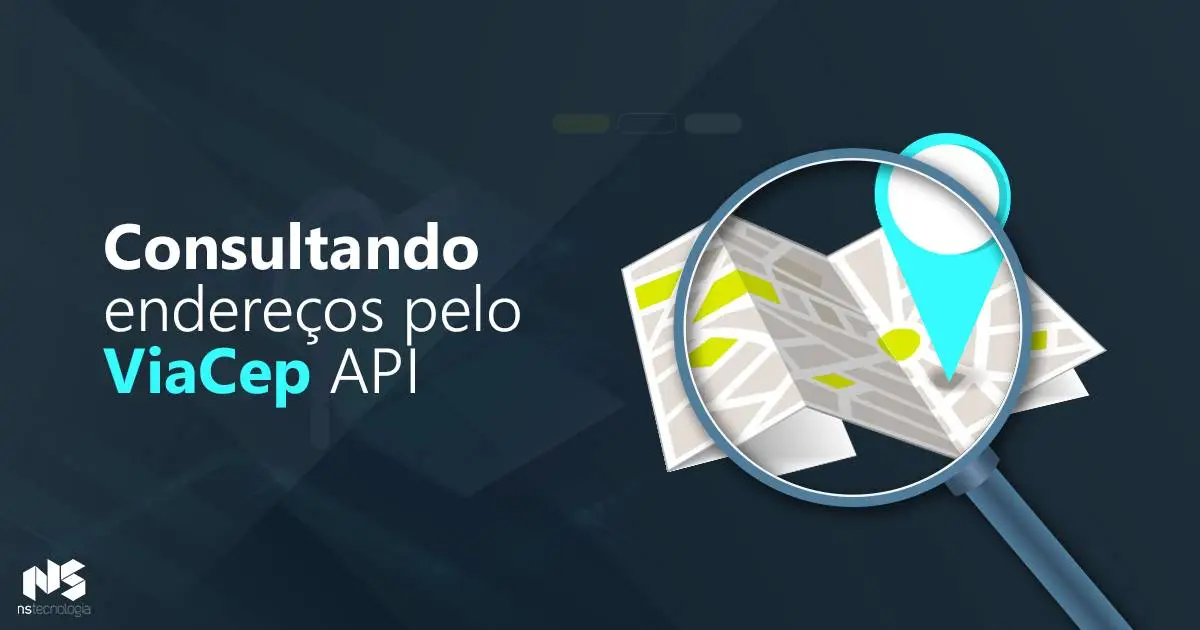

#MissãO 03
Criando um programa autonomo que dispare alertas

In [ ]:
import time # Importa o módulo time para usar a função sleep (pausar a execução)

# --- Configurações do Sistema de Alerta ---
LIMITE_CRITICO = 30 # Define a temperatura em °C a partir da qual um alerta é considerado crítico
INTERVALO_VERIFICACAO = 5 # Intervalo em segundos entre as verificações (para simular autonomia)
EMAIL_ADMIN = "admin@exemplo.com" # Endereço de e-mail para simulação de alerta

# Variável de estado para controlar se um alerta crítico já está ativo
alerta_critico_ativo = False

# --- Funções de Alerta ---
def enviar_alerta_console(mensagem):
    """
    Exibe uma mensagem de alerta no console.
    """
    print("\n!!! ALERTA NO CONSOLE !!!")
    print(mensagem)
    print("------------------------")

def enviar_alerta_email_simulado(destinatario, assunto, corpo):
    """
    Simula o envio de um e-mail de alerta, imprimindo os detalhes no console.
    """
    print("\n--- SIMULANDO ENVIO DE E-MAIL ---")
    print(f"Para: {destinatario}")
    print(f"Assunto: {assunto}")
    print(f"Corpo: {corpo}")
    print("---------------------------------")

# --- Função de Monitoramento (Simulado) ---
def obter_temperatura_sistema():
    """
    Simula a obtenção da temperatura atual do sistema.
    Para este exemplo, solicita a temperatura ao usuário.
    """
    while True:
        try:
            temperatura_str = input(f"Insira a temperatura atual do sistema (limite crítico: {LIMITE_CRITICO}°C) ou 'sair' para encerrar: ")
            if temperatura_str.lower() == 'sair':
                return None # Indica que o usuário quer sair
            temperatura = int(temperatura_str)
            return temperatura
        except ValueError:
            print("Entrada inválida. Por favor, digite um número inteiro para a temperatura.")

# --- Programa Principal Autônomo ---
print("Iniciando monitoramento autônomo do sistema...")
print(f"Alertas serão disparados se a temperatura exceder {LIMITE_CRITICO}°C.")

try:
    while True:
        temperatura_atual = obter_temperatura_sistema()

        if temperatura_atual is None:
            print("Monitoramento encerrado pelo usuário.")
            break # Sai do loop se o usuário digitou 'sair'

        print(f"Verificando temperatura: {temperatura_atual}°C")

        # Verifica a condição crítica
        if temperatura_atual > LIMITE_CRITICO:
            # Se a condição for crítica e o alerta ainda não estiver ativo
            if not alerta_critico_ativo:
                mensagem_alerta = f"SUPER AQUECIMENTO DETECTADO! Temperatura atual: {temperatura_atual}°C"

                enviar_alerta_console(mensagem_alerta)
                enviar_alerta_email_simulado(
                    EMAIL_ADMIN,
                    "ALERTA CRÍTICO: Superaquecimento do Sistema!",
                    mensagem_alerta + " Por favor, verifique imediatamente."
                )
                alerta_critico_ativo = True # Define a flag para indicar que o alerta está ativo
            else:
                print("Alerta crítico já está ativo. Aguardando retorno à normalidade...")
        else:
            # Se a temperatura estiver normal e havia um alerta crítico ativo, reseta a flag
            if alerta_critico_ativo:
                print("Temperatura voltou ao normal. Alerta crítico desativado.")
                alerta_critico_ativo = False
            else:
                print("Temperatura normal. Nenhum alerta necessário.")

        print(f"Aguardando {INTERVALO_VERIFICACAO} segundos para a próxima verificação...")
        time.sleep(INTERVALO_VERIFICACAO) # Aguarda antes da próxima verificação

except KeyboardInterrupt:
    print("\nMonitoramento interrompido manualmente (Ctrl+C).")
except Exception as e:
    print(f"Ocorreu um erro inesperado: {e}")

print("Programa de alerta encerrado.")